In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
#  import TensorFlow/Keras — Sequential for the model, Dense for fully-connected
# layers, Flatten to convert 2D images into 1D vectors for the dense layers

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
# load MNIST directly from Keras's built-in datasets — downloads automatically
# on first run, no manual dataset setup needed (unlike the Kaggle notebook)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_test.shape
# inspect test set dimensions — expect (10000, 28, 28): 10k images, 28x28 pixels each

(10000, 28, 28)

In [4]:
y_train
#  inspect training labels — array of digit classes 0-9

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

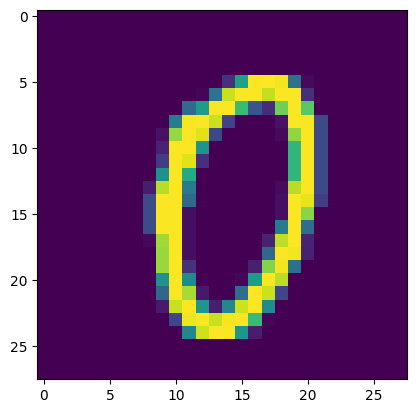

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[1000])
#  display the 1000th training image to visually confirm data loaded correctly

In [6]:
X_train = X_train/255
X_test = X_test/255
#  scale pixel values from [0,255] to [0,1] — neural nets train
# faster and more stably on normalized input

In [8]:
X_train[0]
# commit: view the normalized pixel array to confirm scaling worked (values now between 0-1)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [9]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
#  flatten each 28x28 image into a 784-length 1D vector — dense layers
# need 1D input, not 2D grids

model.add(Dense(128, activation='relu'))
#  hidden layer 1 — 128 neurons, ReLU activation

model.add(Dense(32, activation='relu'))
#  hidden layer 2 — 32 neurons, ReLU activation

model.add(Dense(10, activation='softmax'))
#  output layer — 10 neurons (one per digit class 0-9), softmax
# converts outputs into a probability distribution across the 10 classes

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.summary()
# commit: print architecture and parameter counts to verify the network

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
# sparse_categorical_crossentropy is correct here since y_train contains
# integer class labels (0-9), not one-hot vectors — this loss handles that directly

In [12]:
history = model.fit(X_train, y_train, epochs=25, validation_split=0.2)
#  train for 25 epochs, holding out 20% of training data for validation each epoch

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9165 - loss: 0.2856 - val_accuracy: 0.9588 - val_loss: 0.1432
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9638 - loss: 0.1221 - val_accuracy: 0.9680 - val_loss: 0.1090
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9747 - loss: 0.0833 - val_accuracy: 0.9702 - val_loss: 0.0965
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9804 - loss: 0.0627 - val_accuracy: 0.9732 - val_loss: 0.0908
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9849 - loss: 0.0479 - val_accuracy: 0.9728 - val_loss: 0.0905
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9883 - loss: 0.0368 - val_accuracy: 0.9705 - val_loss: 0.1062
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9900 - loss: 0.0302 - val_accuracy: 0.9748 - val_loss: 0.0954
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9913 - loss: 0.0259 - 

In [13]:
y_prob = model.predict(X_test)
#  get predicted probability distribution (10 values per image) for each test sample

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [14]:
y_pred = y_prob.argmax(axis=1)
#  pick the class with highest probability per sample.
# NOTE: unlike the churn notebook, argmax is CORRECT here — this is true
# multi-class softmax output (10 columns), not single-column sigmoid output.

In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)
#  compute overall test accuracy

0.974

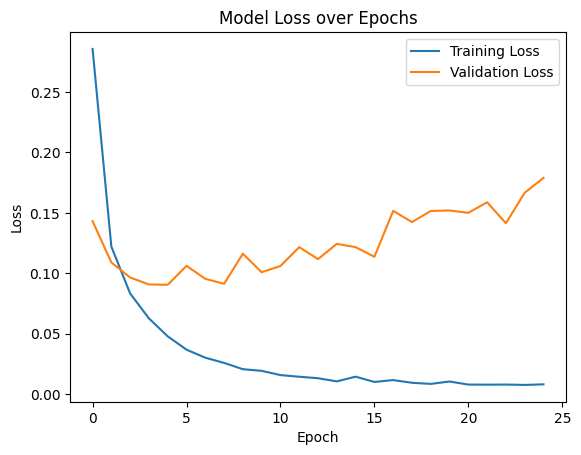

In [16]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
# plot train/val loss curves with proper title, axis labels, and legend

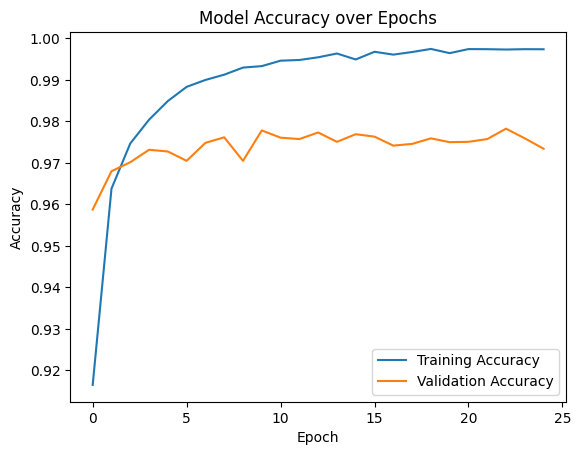

In [17]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
#  plot train/val accuracy curves with proper title, axis labels, and legend

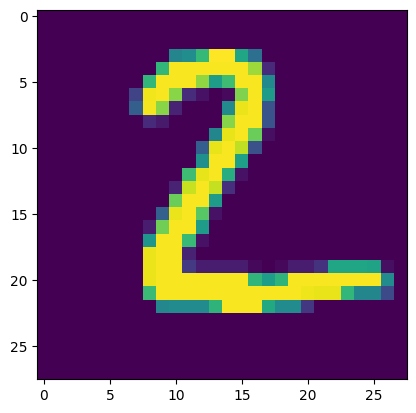

In [18]:
plt.imshow(X_test[1])
# display test image at index 1 to visually inspect before predicting on it

In [19]:
model.predict(X_test[1].reshape(1,28,28)).argmax(axis=1)
#  reshape single image to (1,28,28) — Keras expects a batch dimension even
# for a single prediction — then predict and take the highest-probability class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step


array([2])